In [2]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import regionmask
import flox
from matplotlib import cm

In [3]:
# setup
processed_dir = '../data/FASTMIP_phase2/METEOR_emulations/processed/'

ESM_list = ['ACCESS-ESM1-5','CanESM5', 'IPSL-CM6A-LR', 'MPI-ESM1-2-LR', 'MIROC6']  #(Tier 1 list)
scenario_list = ['SSP2 - Low Emissions', 'SSP2 - Medium Emissions', 'SSP3 - High Emissions', 'SSP1 - Very Low Emissions']
scenarios_short = ['L','M','H','VL']

# select model, variable (tas or pr), scenario, and grid-cell selection for plotting:
model = ESM_list[2]
plot_var = 'tas'
s_idx = 0 
sel_lat = 46.25
sel_lon = 3.75

if plot_var == 'tas':
    ylabel = 'Temperature (K)'
elif plot_var == 'pr':
    ylabel = 'Precipitation'

def glb_mean(ds):
    weights = np.cos(np.deg2rad(ds.lat))
    weights.name = "weights"
    glb_mean = ds.weighted(weights).mean(("lat", "lon"))
    return glb_mean

Plots from the FastMIP protocol: (https://github.com/sarasita/fastMIP/blob/main/requested_output/tour_through_requested_output.ipynb)

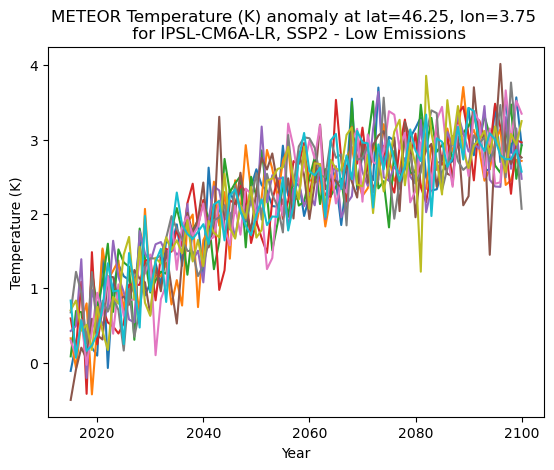

In [4]:
# plot ensemble timeseries for a given point:
data = xr.open_dataset(f"{processed_dir}/{plot_var}_{scenarios_short[s_idx]}_meteor_gridcell_selected-realisations.nc")

plt.figure()
plt.plot(data['year'].values, data[plot_var].sel(esm=model).sel(lat=sel_lat, lon=sel_lon, method='nearest').values)
plt.xlabel('Year')
plt.ylabel(ylabel) 
plt.title(f'METEOR {ylabel} anomaly at lat={sel_lat}, lon={sel_lon} \n for {model}, {scenario_list[s_idx]}')
plt.show()


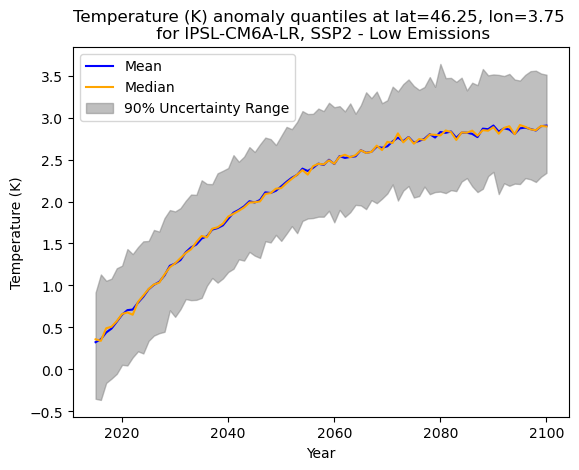

In [5]:
# plotting the median and mean temperature anomaly
# along with the 90% uncertainty range for the selected grid-cell
example_data = xr.open_dataset(f"{processed_dir}/{plot_var}_{scenarios_short[s_idx]}_meteor_gridcell_quantiles-by-ESM.nc")

plt.figure()
plt.plot(example_data['year'].values, example_data['tas_mean'].sel(esm=model).sel(lat=sel_lat, lon=sel_lon, method='nearest').values, label='Mean', color='blue')
plt.plot(example_data['year'].values, example_data['tas'].sel(esm=model).sel(lat=sel_lat, lon=sel_lon, quantile=0.5, method='nearest').values, label='Median', color='orange')
plt.fill_between(example_data['year'].values,
                 example_data['tas'].sel(esm=model).sel(lat=sel_lat, lon=sel_lon, quantile=0.05, method='nearest').values.squeeze(),
                 example_data['tas'].sel(esm=model).sel(lat=sel_lat, lon=sel_lon, quantile=0.95, method='nearest').values.squeeze(),
                 color='gray', alpha=0.5, label='90% Uncertainty Range')
plt.xlabel('Year')
plt.ylabel(ylabel)  # Assuming the data is temperature in Kelvin
plt.title(f'{ylabel} anomaly quantiles at lat={sel_lat}, lon={sel_lon} \n for {model}, {scenario_list[s_idx]}')
plt.legend()
plt.show()


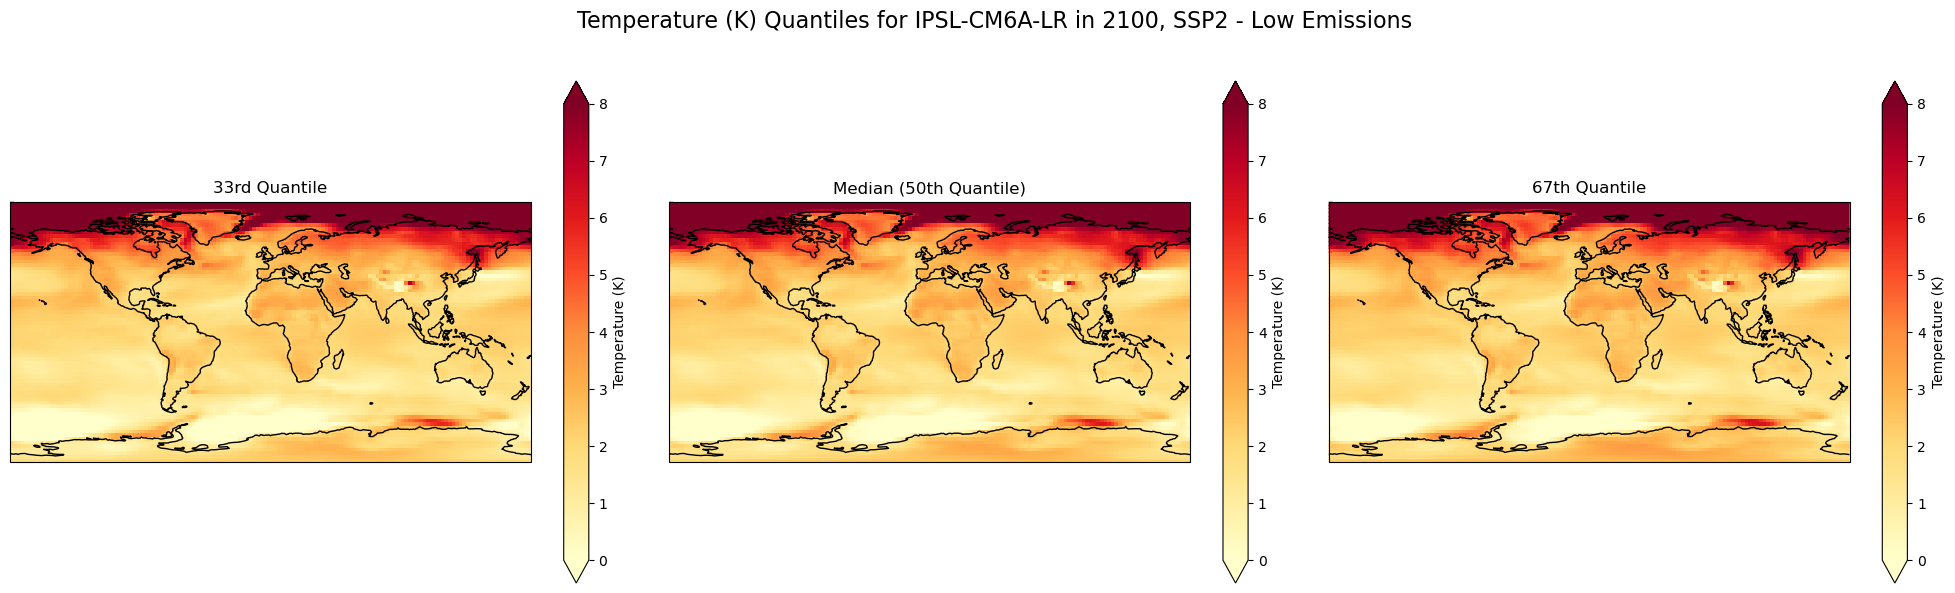

In [6]:
# Generate maps for the 33rd, median, and 67th quantiles for the selected ESM and year 2100

quantiles_to_plot = [0.33, 0.5, 0.67]
titles = ['33rd Quantile', 'Median (50th Quantile)', '67th Quantile']
cmap = 'YlOrRd'

fig, axes = plt.subplots(1, 3, figsize=(20, 6), subplot_kw={'projection': ccrs.PlateCarree()})

for ax, quantile, title in zip(axes, quantiles_to_plot, titles):
    data = example_data['tas'].sel(quantile=quantile, esm=model, year=2100)
    data.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        cbar_kwargs={"label": ylabel},
        vmin = 0,
        vmax = 8
    )
    ax.coastlines()
    ax.set_title(title)

fig.suptitle(f'{ylabel} Quantiles for {model} in 2100, {scenario_list[s_idx]}', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to make space for the suptitle
plt.show()


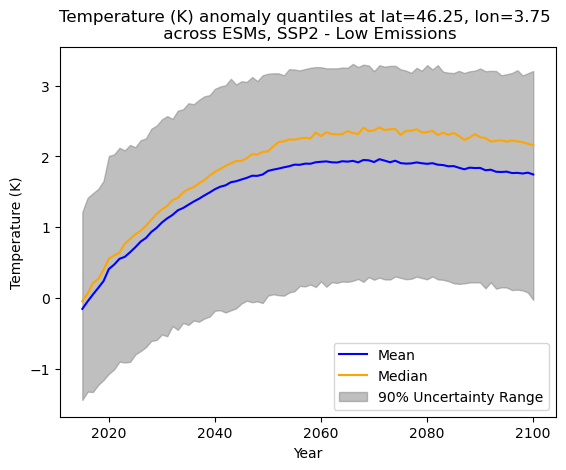

In [7]:
# plot the median and mean temperature anomaly
# along with the 90% uncertainty range computed across ESMs
# for the selected grid-cell
example_data = xr.open_dataset(f"{processed_dir}/{plot_var}_{scenarios_short[s_idx]}_meteor_gridcell_quantiles-across-ESM.nc")

plt.figure()
plt.plot(example_data['year'].values, example_data[f'{plot_var}_mean'].sel(lat=sel_lat, lon=sel_lon, method='nearest').values, label='Mean', color='blue')
plt.plot(example_data['year'].values, example_data[plot_var].sel(lat=sel_lat, lon=sel_lon, quantile=0.5, method='nearest').values, label='Median', color='orange')
plt.fill_between(example_data['year'].values,
                 example_data[plot_var].sel(lat=sel_lat, lon=sel_lon, quantile=0.05, method='nearest').values,
                 example_data[plot_var].sel(lat=sel_lat, lon=sel_lon, quantile=0.95, method='nearest').values,
                 color='gray', alpha=0.5, label='90% Uncertainty Range')
plt.xlabel('Year')
plt.ylabel(ylabel)  # Assuming the data is temperature in Kelvin
plt.title(f'{ylabel} anomaly quantiles at lat={sel_lat}, lon={sel_lon} \n across ESMs, {scenario_list[s_idx]}')
plt.legend()
plt.show()


In [10]:
xr.open_dataset(f"{processed_dir}/{plot_var}_{scenarios_short[s_idx]}_meteor_regional_quantiles-by-ESM.nc")

<xarray.Dataset> Size: 827kB
Dimensions:   (year: 86, esm: 5, mask: 24, quantile: 9)
Coordinates:
  * year      (year) float64 688B 2.015e+03 2.016e+03 ... 2.099e+03 2.1e+03
  * esm       (esm) <U13 260B 'ACCESS-ESM1-5' 'CanESM5' ... 'MIROC6'
  * mask      (mask) float64 192B 0.0 2.0 5.0 7.0 8.0 ... 34.0 36.0 37.0 -1.0
  * quantile  (quantile) float64 72B 0.01 0.025 0.05 0.33 ... 0.95 0.975 0.99
Data variables:
    tas_mean  (year, esm, mask) float64 83kB ...
    tas       (quantile, year, esm, mask) float64 743kB ...
Attributes:
    scenario:               regional quantiles-by-ESM for scenario L
    FAIR ensemble members:  [1003234 1137882 1164278 1214250 1232675 1380744 ...
    meteor_version:         tag v1.6.0-10-g95e4345
    reference:              https://doi.org/10.5194/egusphere-2026-2029 [prep...
    ensemble_info:          Full ensemble is 200 members per ESM per scenario...
    fair_calibration:       Fair calibration v1.6.0
    authors:                Maura Dewey (maura.dewey@cicero.oslo.no), Marit S...
    date:                   2026-06-01T09:13:06.514338+00:00

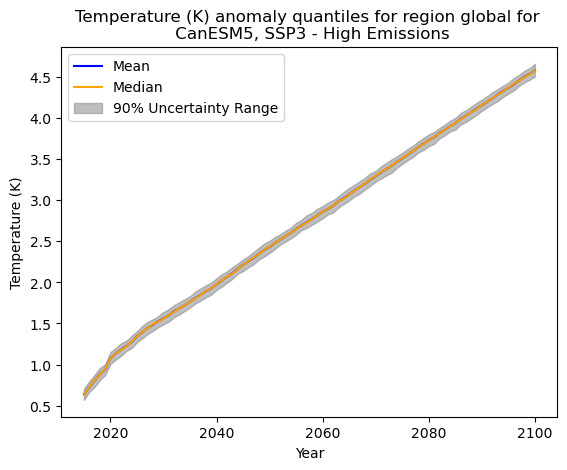

In [14]:
# plot the median and mean temperature anomaly
# along with the 90% uncertainty range for a selected region
# and ESM
s_idx = 2
example_data = xr.open_dataset(f"{processed_dir}/{plot_var}_{scenarios_short[s_idx]}_meteor_regional_quantiles-by-ESM.nc")
selected_regions = [-1, 34, 17]
sel_mask = selected_regions[0]  # selecting a region
#region_name = regionmask.defined_regions.ar6.land[sel_mask].name # getting the name of the region
region_name = 'global'
model = ESM_list[1]

plt.figure()
plt.plot(example_data['year'].values, example_data[f'{plot_var}_mean'].sel(mask = sel_mask, esm = model ).values, label='Mean', color='blue')
plt.plot(example_data['year'].values, example_data[plot_var].sel(mask = sel_mask, quantile=0.5, esm = model ).values, label='Median', color='orange')
plt.fill_between(example_data['year'].values,
                 example_data[plot_var].sel(mask = sel_mask, quantile=0.05, esm = model ).values,
                 example_data[plot_var].sel(mask = sel_mask, quantile=0.95, esm = model ).values,
                 color='gray', alpha=0.5, label='90% Uncertainty Range')
plt.xlabel('Year')
plt.ylabel(ylabel)  # Assuming the data is temperature in Kelvin
plt.title(f'{ylabel} anomaly quantiles for region {region_name} for \n {model}, {scenario_list[s_idx]}')
plt.legend()
plt.show()


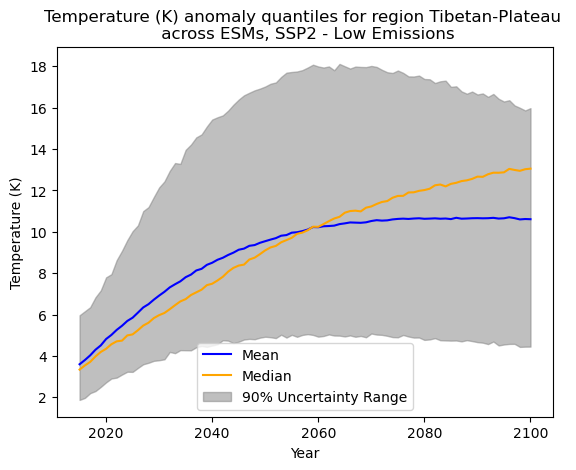

In [9]:
# plot the median and mean temperature anomaly
# along with the 90% uncertainty range for a selected region
# across ESMs
example_data = xr.open_dataset(f"{processed_dir}/{plot_var}_{scenarios_short[s_idx]}_meteor_regional_quantiles-across-ESM.nc")
sel_mask = selected_regions[1]  # selecting a region
region_name = regionmask.defined_regions.ar6.land[sel_mask].name # getting the name of the region

plt.figure()
plt.plot(example_data['year'].values, example_data[f'{plot_var}_mean'].sel(mask = sel_mask).values, label='Mean', color='blue')
plt.plot(example_data['year'].values, example_data[f'{plot_var}'].sel(mask = sel_mask, quantile=0.5).values, label='Median', color='orange')
plt.fill_between(example_data['year'].values,
                 example_data[f'{plot_var}'].sel(mask = sel_mask, quantile=0.05).values,
                 example_data[f'{plot_var}'].sel(mask = sel_mask, quantile=0.95).values,
                 color='gray', alpha=0.5, label='90% Uncertainty Range')
plt.xlabel('Year')
plt.ylabel(ylabel)  # Assuming the data is temperature in Kelvin
plt.title(f'{ylabel} anomaly quantiles for region {region_name} \n across ESMs, {scenario_list[s_idx]}')
plt.legend()
plt.show()


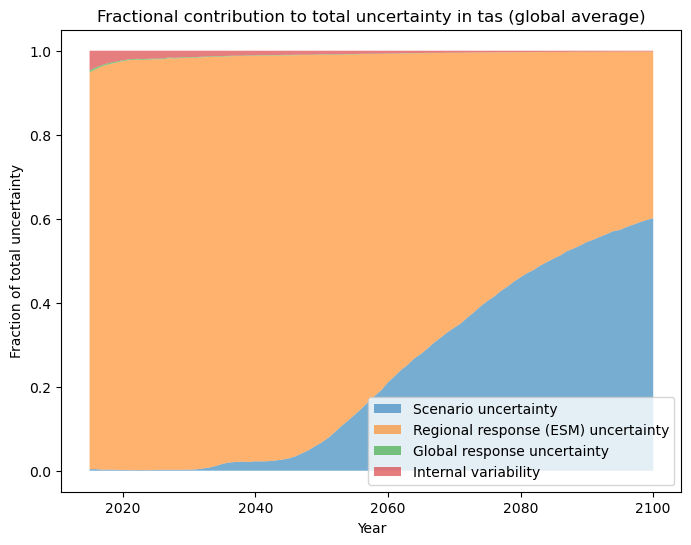

In [10]:
# plot across-scenario regional uncertainty
u_regional_df = xr.open_dataset(f"{processed_dir}/{plot_var}_cross-scenario_meteor_regional_across-scenario-uncertainty.nc")
# computing the total variance as the sum of the individual variances
u_regional_df['var_total'] = u_regional_df['var_scenario'] + u_regional_df['var_esm'] + u_regional_df['var_global'] + u_regional_df['var_int']

sel_region = -1  # global
plt.figure(figsize=(8, 6))

# Calculate fractional contributions
scenario_uncertainty = u_regional_df['var_scenario'].sel(mask=sel_region) / u_regional_df['var_total'].sel(mask=sel_region)
esm_uncertainty = u_regional_df['var_esm'].sel(mask=sel_region) / u_regional_df['var_total'].sel(mask=sel_region)
glob_uncertainty = u_regional_df['var_global'].sel(mask=sel_region) / u_regional_df['var_total'].sel(mask=sel_region)
int_uncertainty = u_regional_df['var_int'].sel(mask=sel_region) / u_regional_df['var_total'].sel(mask=sel_region)

# Stack the uncertainties
plt.fill_between(u_regional_df['year'], 0, scenario_uncertainty, label='Scenario uncertainty', alpha=0.6)
plt.fill_between(u_regional_df['year'], scenario_uncertainty, scenario_uncertainty + esm_uncertainty, label='Regional response (ESM) uncertainty', alpha=0.6)
plt.fill_between(u_regional_df['year'], scenario_uncertainty + esm_uncertainty, scenario_uncertainty + esm_uncertainty + glob_uncertainty, label='Global response uncertainty', alpha=0.6)
plt.fill_between(u_regional_df['year'], scenario_uncertainty + esm_uncertainty + glob_uncertainty, 1, label='Internal variability', alpha=0.6)

# Add labels and title
plt.title(f'Fractional contribution to total uncertainty in {plot_var} (global average)')
plt.ylabel('Fraction of total uncertainty')
plt.xlabel('Year')
plt.legend(loc = 'lower right')
plt.show()

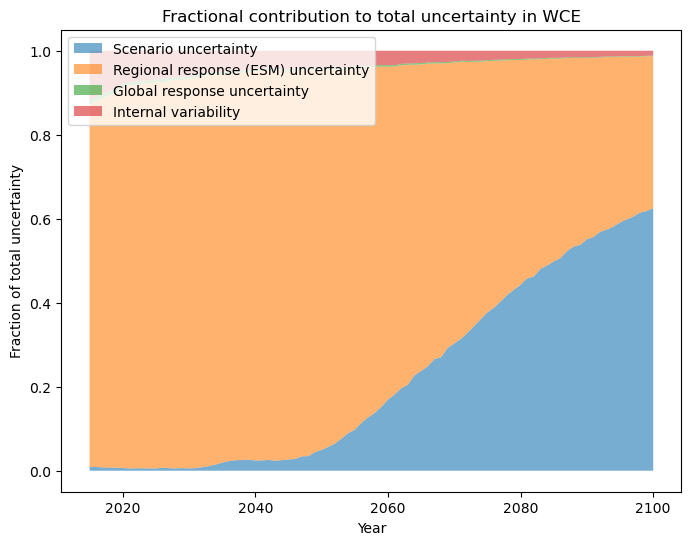

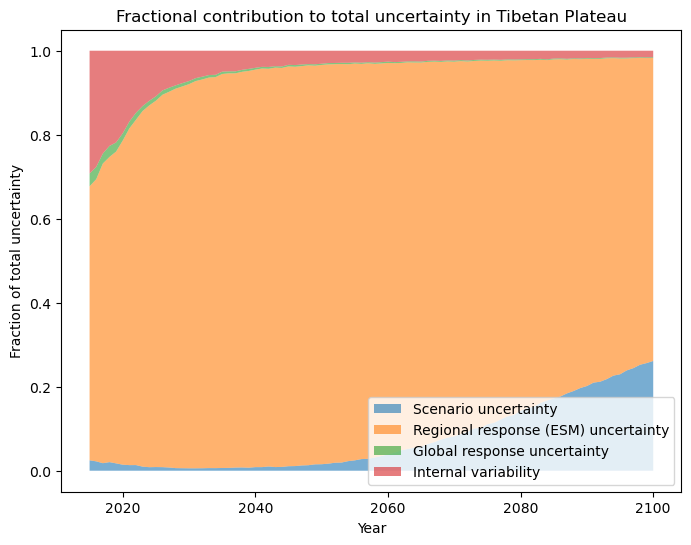

In [11]:
# the resulting plot can vary by region and in, particular,
# the smallter the region, the larger the contribution of internal variability
sel_region = 17  # CENTRAL EUROPE
plt.figure(figsize=(8, 6))

# Calculate fractional contributions
scenario_uncertainty = u_regional_df['var_scenario'].sel(mask=sel_region) / u_regional_df['var_total'].sel(mask=sel_region)
esm_uncertainty = u_regional_df['var_esm'].sel(mask=sel_region) / u_regional_df['var_total'].sel(mask=sel_region)
glob_uncertainty = u_regional_df['var_global'].sel(mask=sel_region) / u_regional_df['var_total'].sel(mask=sel_region)
int_uncertainty = u_regional_df['var_int'].sel(mask=sel_region) / u_regional_df['var_total'].sel(mask=sel_region)

# Stack the uncertainties
plt.fill_between(u_regional_df['year'], 0, scenario_uncertainty, label='Scenario uncertainty', alpha=0.6)
plt.fill_between(u_regional_df['year'], scenario_uncertainty, scenario_uncertainty + esm_uncertainty, label='Regional response (ESM) uncertainty', alpha=0.6)
plt.fill_between(u_regional_df['year'], scenario_uncertainty + esm_uncertainty, scenario_uncertainty + esm_uncertainty + glob_uncertainty, label='Global response uncertainty', alpha=0.6)
plt.fill_between(u_regional_df['year'], scenario_uncertainty + esm_uncertainty + glob_uncertainty, 1, label='Internal variability', alpha=0.6)

# Add labels and title
plt.title('Fractional contribution to total uncertainty in WCE')
plt.ylabel('Fraction of total uncertainty')
plt.xlabel('Year')
plt.legend(loc = 'upper left')
plt.show()


sel_region = 34  # Tibetan Plateau
plt.figure(figsize=(8, 6))

# Calculate fractional contributions
scenario_uncertainty = u_regional_df['var_scenario'].sel(mask=sel_region) / u_regional_df['var_total'].sel(mask=sel_region)
esm_uncertainty = u_regional_df['var_esm'].sel(mask=sel_region) / u_regional_df['var_total'].sel(mask=sel_region)
glob_uncertainty = u_regional_df['var_global'].sel(mask=sel_region) / u_regional_df['var_total'].sel(mask=sel_region)
int_uncertainty = u_regional_df['var_int'].sel(mask=sel_region) / u_regional_df['var_total'].sel(mask=sel_region)

# Stack the uncertainties
plt.fill_between(u_regional_df['year'], 0, scenario_uncertainty, label='Scenario uncertainty', alpha=0.6)
plt.fill_between(u_regional_df['year'], scenario_uncertainty, scenario_uncertainty + esm_uncertainty, label='Regional response (ESM) uncertainty', alpha=0.6)
plt.fill_between(u_regional_df['year'], scenario_uncertainty + esm_uncertainty, scenario_uncertainty + esm_uncertainty + glob_uncertainty, label='Global response uncertainty', alpha=0.6)
plt.fill_between(u_regional_df['year'], scenario_uncertainty + esm_uncertainty + glob_uncertainty, 1, label='Internal variability', alpha=0.6)

# Add labels and title
plt.title('Fractional contribution to total uncertainty in Tibetan Plateau')
plt.ylabel('Fraction of total uncertainty')
plt.xlabel('Year')
plt.legend(loc = 'lower right')
plt.show()


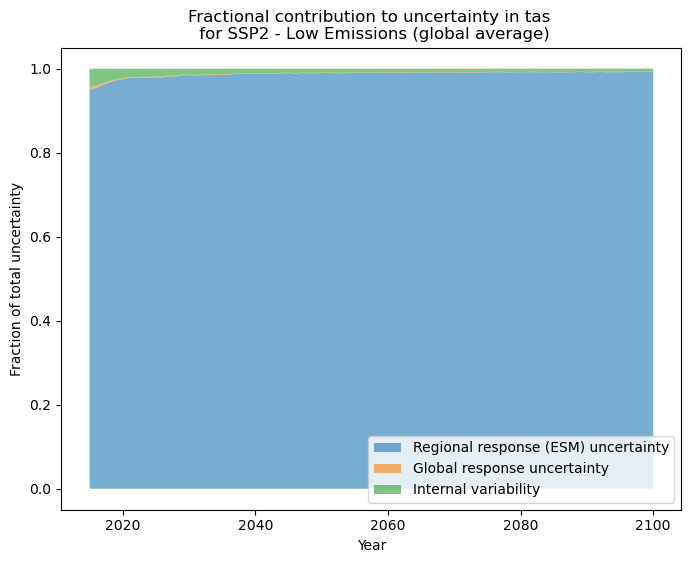

In [12]:
# plot within scenario uncertainty
u_grid_df = xr.open_dataset(f"{processed_dir}/{plot_var}_{scenarios_short[s_idx]}_meteor_regional_uncertainty.nc")
# computing the total variance as the sum of the individual variances
u_grid_df['var_total'] =  u_grid_df['var_esm'] + u_grid_df['var_global'] + u_grid_df['var_int']

plt.figure(figsize=(8, 6))

sel_region = -1 #global
# Calculate fractional contributions
esm_uncertainty = u_grid_df['var_esm'].sel(mask=sel_region) / u_grid_df['var_total'].sel(mask=sel_region)
glob_uncertainty = u_grid_df['var_global'].sel(mask=sel_region) / u_grid_df['var_total'].sel(mask=sel_region)
int_uncertainty = u_grid_df['var_int'].sel(mask=sel_region) / u_grid_df['var_total'].sel(mask=sel_region)

# Stack the uncertainties
plt.fill_between(u_grid_df['year'], 0, esm_uncertainty, label='Regional response (ESM) uncertainty', alpha=0.6)
plt.fill_between(u_grid_df['year'], esm_uncertainty, esm_uncertainty + glob_uncertainty, label='Global response uncertainty', alpha=0.6)
plt.fill_between(u_grid_df['year'], esm_uncertainty + glob_uncertainty, 1, label='Internal variability', alpha=0.6)

# Add labels and title
plt.title(f'Fractional contribution to uncertainty in {plot_var} \n for {scenario_list[s_idx]} (global average)')
plt.ylabel('Fraction of total uncertainty')
plt.xlabel('Year')
plt.legend(loc = 'lower right')
plt.show()

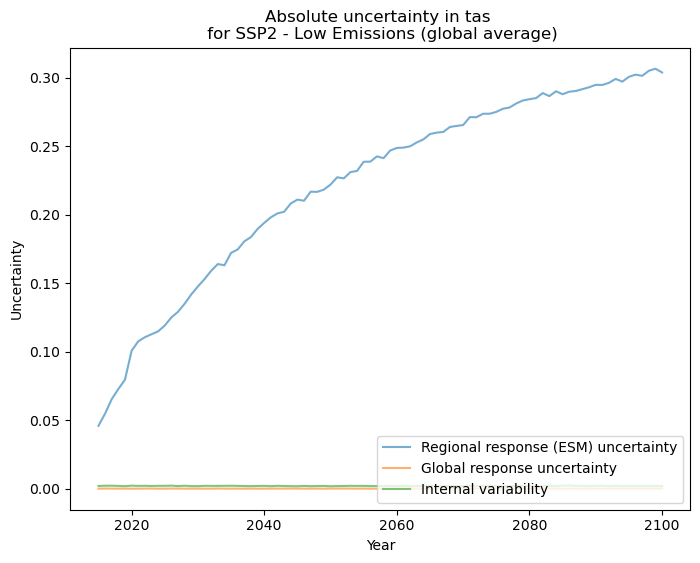

In [13]:
# plot absolute values of regional uncertainty, not fractions of total:

# plot within scenario uncertainty
u_grid_df = xr.open_dataset(f"{processed_dir}/{plot_var}_{scenarios_short[s_idx]}_meteor_regional_uncertainty.nc")

plt.figure(figsize=(8, 6))

sel_region = -1 #global

# Stack the uncertainties
plt.plot(u_grid_df['year'], u_grid_df['var_esm'].sel(mask=sel_region), label='Regional response (ESM) uncertainty', alpha=0.6)
plt.plot(u_grid_df['year'], u_grid_df['var_global'].sel(mask=sel_region), label='Global response uncertainty', alpha=0.6)
plt.plot(u_grid_df['year'], u_grid_df['var_int'].sel(mask=sel_region), label='Internal variability', alpha=0.6)

# Add labels and title
plt.title(f'Absolute uncertainty in {plot_var} \n for {scenario_list[s_idx]} (global average)')
plt.ylabel('Uncertainty')
plt.xlabel('Year')
plt.legend(loc = 'lower right')
plt.show()

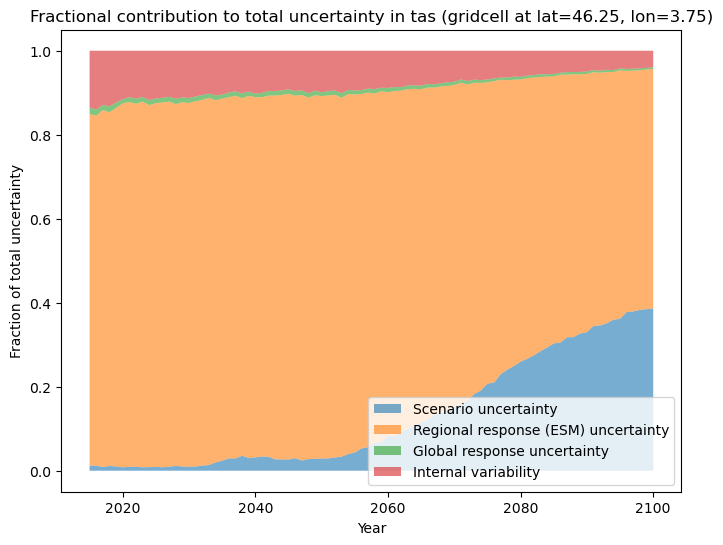

In [14]:
# plot across-scenario gridcell uncertainty
u_gridcell_df = xr.open_dataset(f"{processed_dir}/{plot_var}_cross-scenario_meteor_gridcell_across-scenario-uncertainty.nc")
# computing the total variance as the sum of the individual variances
u_gridcell_df['var_total'] = u_gridcell_df['var_scenario'] + u_gridcell_df['var_esm'] + u_gridcell_df['var_global'] + u_gridcell_df['var_int']

plt.figure(figsize=(8, 6))

# Calculate fractional contributions
scenario_uncertainty = u_gridcell_df['var_scenario'].sel(lat=sel_lat, lon=sel_lon) / u_gridcell_df['var_total'].sel(lat=sel_lat, lon=sel_lon)
esm_uncertainty = u_gridcell_df['var_esm'].sel(lat=sel_lat, lon=sel_lon) / u_gridcell_df['var_total'].sel(lat=sel_lat, lon=sel_lon)
glob_uncertainty = u_gridcell_df['var_global'].sel(lat=sel_lat, lon=sel_lon) / u_gridcell_df['var_total'].sel(lat=sel_lat, lon=sel_lon)
int_uncertainty = u_gridcell_df['var_int'].sel(lat=sel_lat, lon=sel_lon) / u_gridcell_df['var_total'].sel(lat=sel_lat, lon=sel_lon)

# Stack the uncertainties
plt.fill_between(u_gridcell_df['year'], 0, scenario_uncertainty, label='Scenario uncertainty', alpha=0.6)
plt.fill_between(u_gridcell_df['year'], scenario_uncertainty, scenario_uncertainty + esm_uncertainty, label='Regional response (ESM) uncertainty', alpha=0.6)
plt.fill_between(u_gridcell_df['year'], scenario_uncertainty + esm_uncertainty, scenario_uncertainty + esm_uncertainty + glob_uncertainty, label='Global response uncertainty', alpha=0.6)
plt.fill_between(u_gridcell_df['year'], scenario_uncertainty + esm_uncertainty + glob_uncertainty, 1, label='Internal variability', alpha=0.6)

# Add labels and title
plt.title(f'Fractional contribution to total uncertainty in {plot_var} (gridcell at lat={sel_lat}, lon={sel_lon})')
plt.ylabel('Fraction of total uncertainty')
plt.xlabel('Year')
plt.legend(loc = 'lower right')
plt.show()

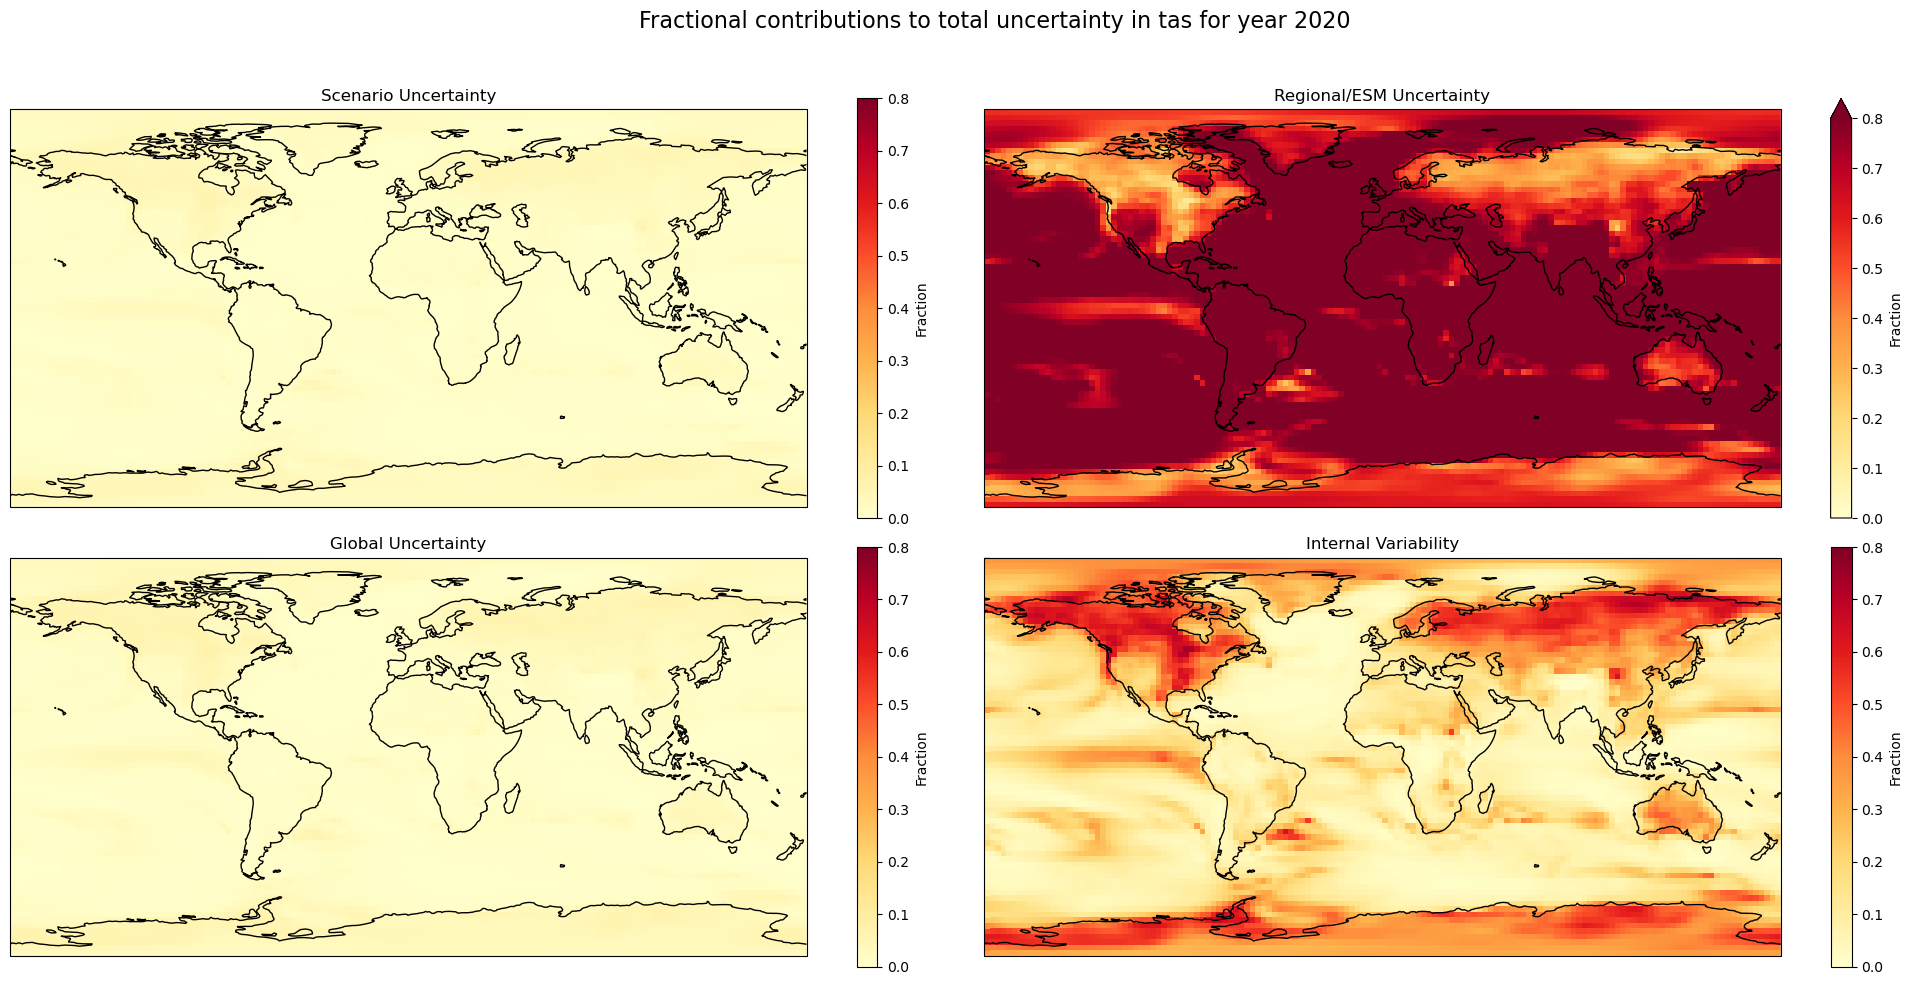

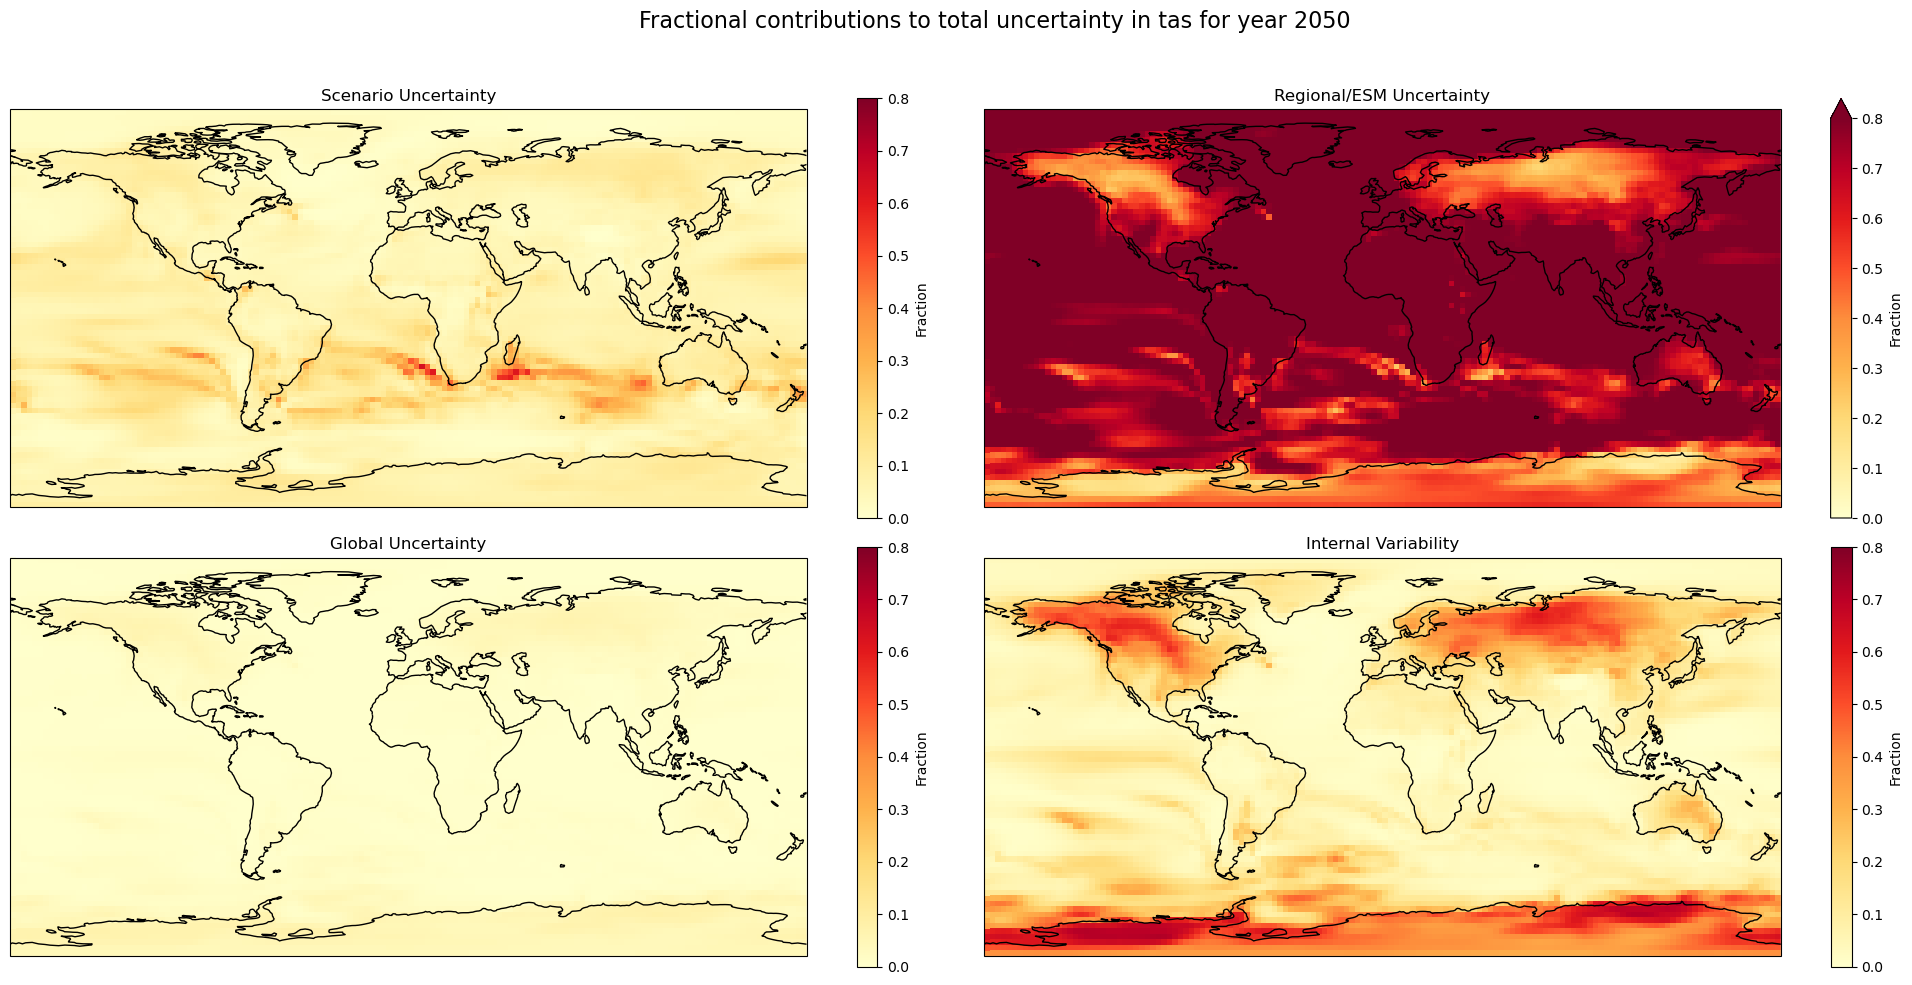

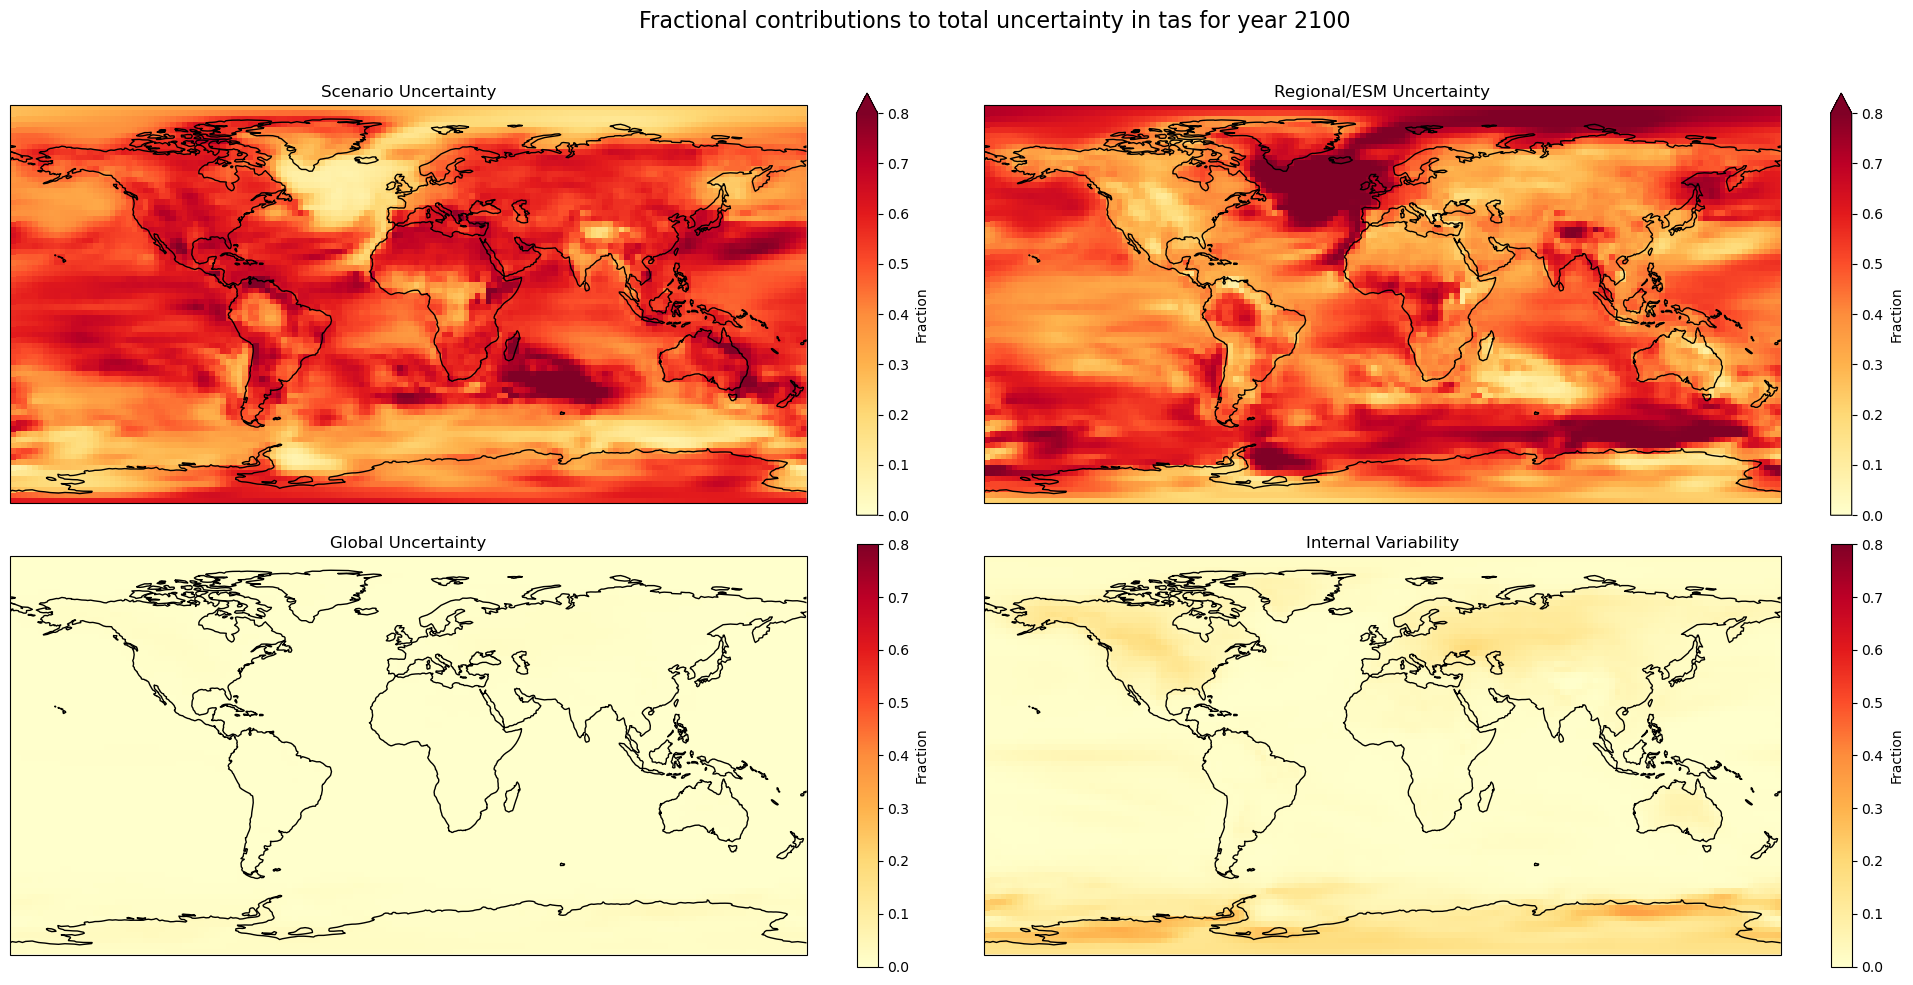

In [15]:
# we can use the grid-cell level data to plot contributions on
# a map and investigate how these maps evolve over time
for sel_year in [2020, 2050, 2100]:
    fig, axes = plt.subplots(2, 2, figsize=(20, 10), subplot_kw={'projection': ccrs.PlateCarree()})
    fractional_contributions = ['var_scenario', 'var_esm', 'var_global', 'var_int']
    titles = ['Scenario Uncertainty', 'Regional/ESM Uncertainty', 'Global Uncertainty', 'Internal Variability']
    cmaps = ['YlOrRd']*4

    for ax, var, title, cmap in zip(axes.flat, fractional_contributions, titles, cmaps):
        data = (u_gridcell_df[var].sel(year=sel_year) / u_gridcell_df['var_total'].sel(year=sel_year))
        data.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cmap=cmap,
            vmin=0,
            vmax=0.8,
            cbar_kwargs={"label": "Fraction"}
        )
        ax.coastlines()
        ax.set_title(title)

    fig.suptitle(f'Fractional contributions to total uncertainty in {plot_var} for year {sel_year}', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to make space for the suptitle
    plt.show()

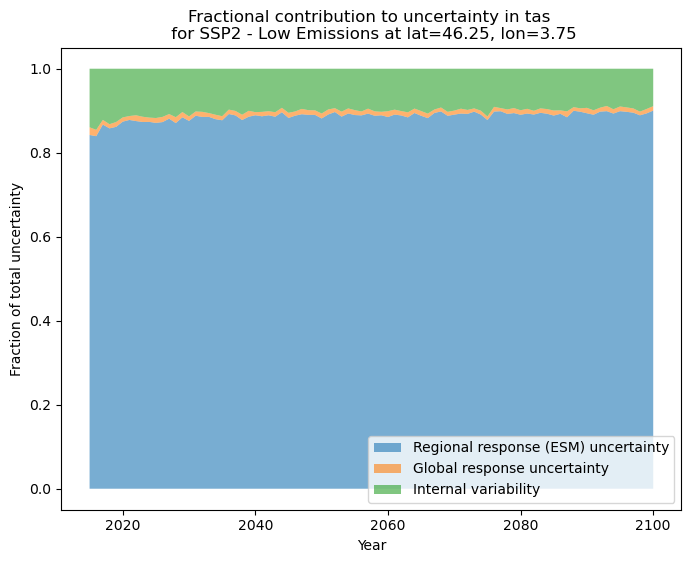

In [16]:
# plot within scenario uncertainty
u_grid_df = xr.open_dataset(f"{processed_dir}/{plot_var}_{scenarios_short[s_idx]}_meteor_gridcell_uncertainty.nc")
# computing the total variance as the sum of the individual variances
u_grid_df['var_total'] =  u_grid_df['var_esm'] + u_grid_df['var_global'] + u_grid_df['var_int']

plt.figure(figsize=(8, 6))

# Calculate fractional contributions
esm_uncertainty = u_grid_df['var_esm'].sel(lat=sel_lat, lon=sel_lon) / u_grid_df['var_total'].sel(lat=sel_lat, lon=sel_lon)
glob_uncertainty = u_grid_df['var_global'].sel(lat=sel_lat, lon=sel_lon) / u_grid_df['var_total'].sel(lat=sel_lat, lon=sel_lon)
int_uncertainty = u_grid_df['var_int'].sel(lat=sel_lat, lon=sel_lon) / u_grid_df['var_total'].sel(lat=sel_lat, lon=sel_lon)

# Stack the uncertainties
plt.fill_between(u_grid_df['year'], 0, esm_uncertainty, label='Regional response (ESM) uncertainty', alpha=0.6)
plt.fill_between(u_grid_df['year'], esm_uncertainty, esm_uncertainty + glob_uncertainty, label='Global response uncertainty', alpha=0.6)
plt.fill_between(u_grid_df['year'], esm_uncertainty + glob_uncertainty, 1, label='Internal variability', alpha=0.6)

# Add labels and title
plt.title(f'Fractional contribution to uncertainty in {plot_var} \n for {scenario_list[s_idx]} at lat={sel_lat}, lon={sel_lon}')
plt.ylabel('Fraction of total uncertainty')
plt.xlabel('Year')
plt.legend(loc = 'lower right')
plt.show()


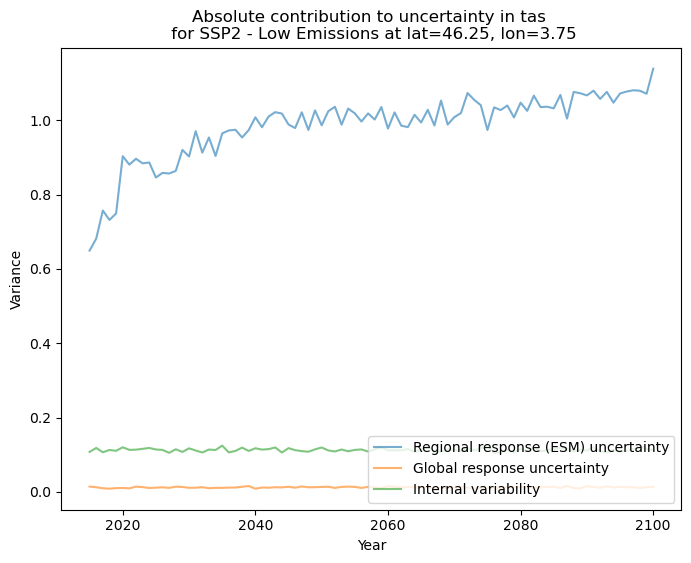

In [17]:
# plot within scenario uncertainty
u_grid_df = xr.open_dataset(f"{processed_dir}/{plot_var}_{scenarios_short[s_idx]}_meteor_gridcell_uncertainty.nc")
# computing the total variance as the sum of the individual variances
plt.figure(figsize=(8, 6))

# Stack the uncertainties
plt.plot(u_grid_df['year'], u_grid_df['var_esm'].sel(lat=sel_lat, lon=sel_lon), label='Regional response (ESM) uncertainty', alpha=0.6)
plt.plot(u_grid_df['year'], u_grid_df['var_global'].sel(lat=sel_lat, lon=sel_lon), label='Global response uncertainty', alpha=0.6)
plt.plot(u_grid_df['year'], u_grid_df['var_int'].sel(lat=sel_lat, lon=sel_lon), label='Internal variability', alpha=0.6)

# Add labels and title
plt.title(f'Absolute contribution to uncertainty in {plot_var} \n for {scenario_list[s_idx]} at lat={sel_lat}, lon={sel_lon}')
plt.ylabel('Variance')
plt.xlabel('Year')
plt.legend(loc = 'lower right')
plt.show()

/scratch/tmp/ipykernel_814385/3238909221.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  esm_colors = cm.get_cmap('Set2', len(ESM_list))


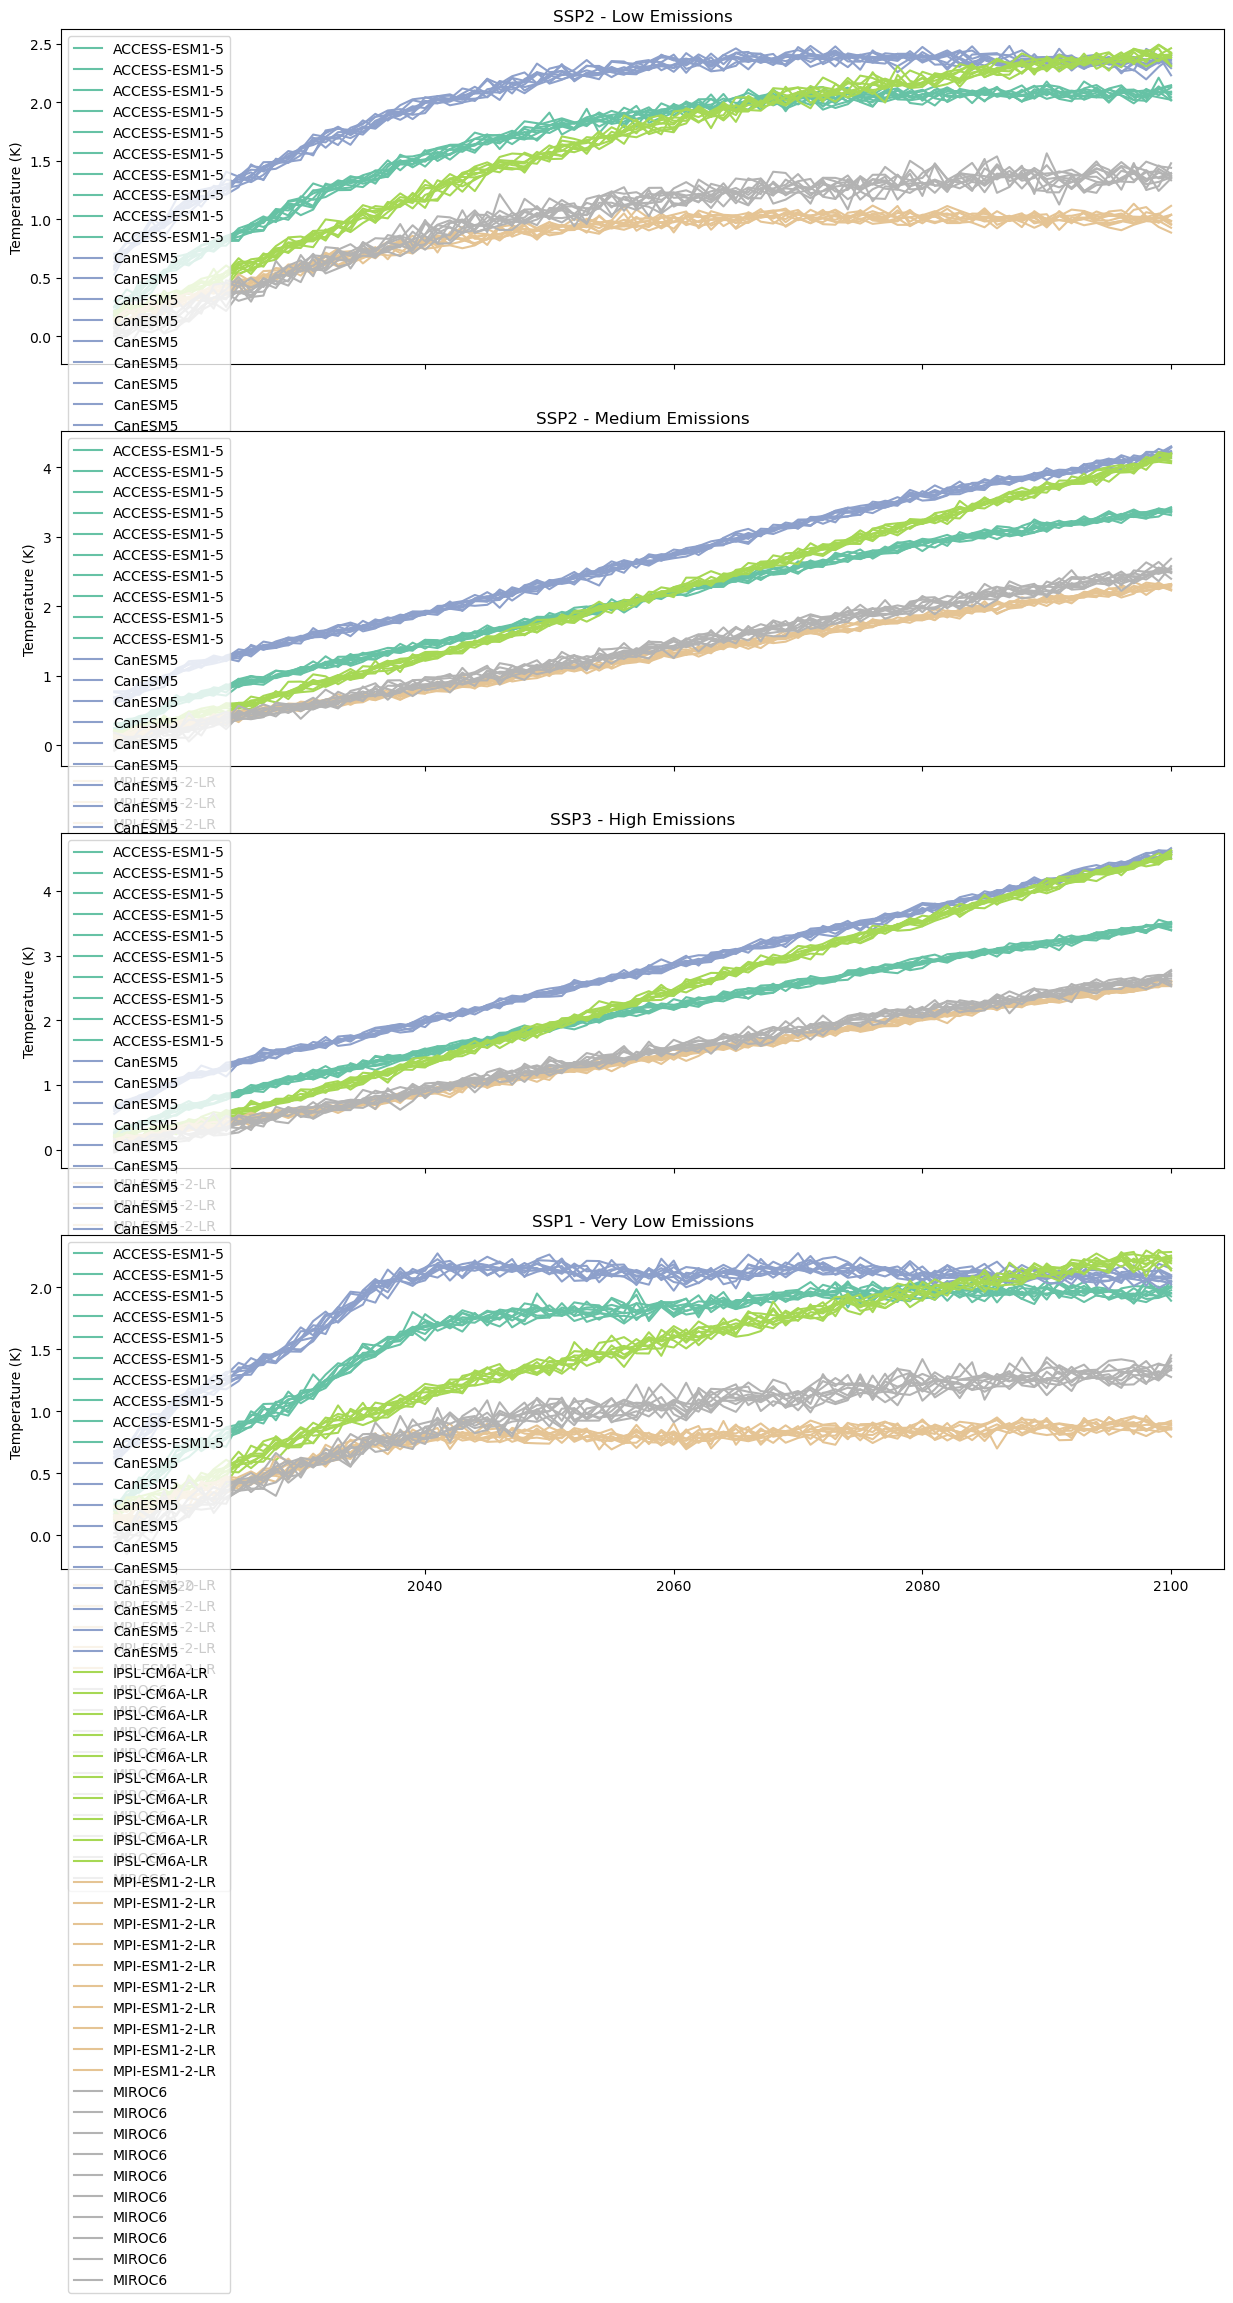

In [ ]:
#plot selected realisations for all scenarios:

esm_colors = cm.get_cmap('Set2', len(ESM_list))

tas_L = xr.open_dataset(f"{processed_dir}/tas_L_meteor_gridcell_selected-realisations.nc")
tas_M = xr.open_dataset(f"{processed_dir}/tas_M_meteor_gridcell_selected-realisations.nc")
tas_H = xr.open_dataset(f"{processed_dir}/tas_H_meteor_gridcell_selected-realisations.nc")
tas_VL = xr.open_dataset(f"{processed_dir}/tas_VL_meteor_gridcell_selected-realisations.nc")



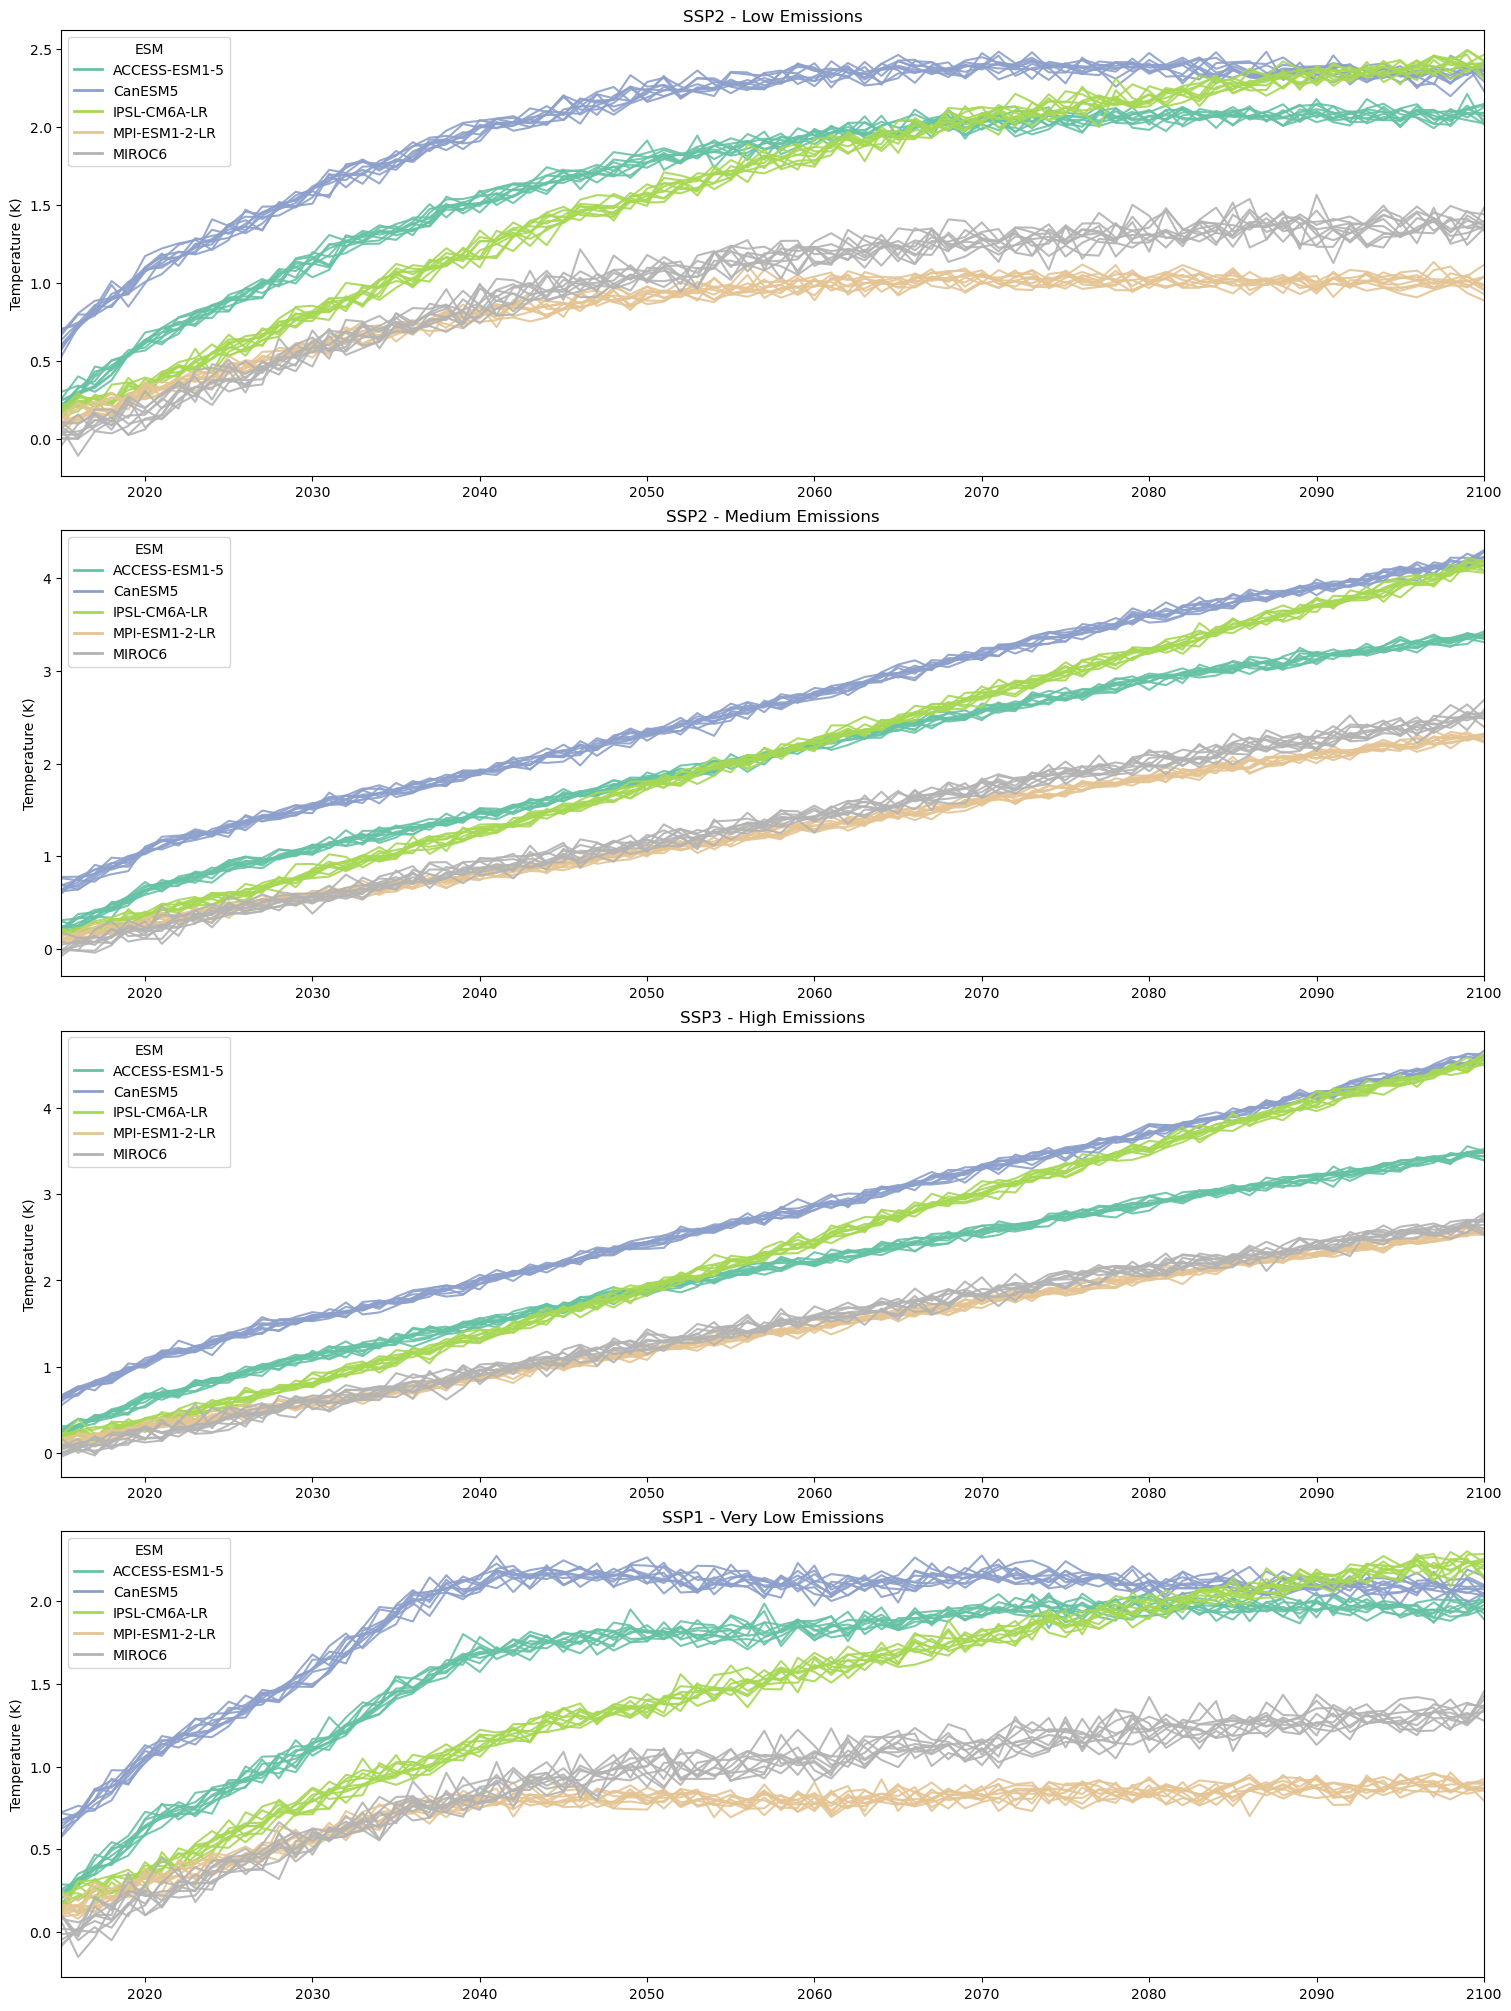

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig, axs = plt.subplots(4, 1, figsize=(15, 20), layout="constrained")

legend_handles = [
    Line2D([0], [0],
           color=esm_colors(ESM_list.index(esm)),
           lw=2,
           label=esm)
    for i, esm in enumerate(ESM_list)
]

datasets = [tas_L, tas_M, tas_H, tas_VL]

for i, (tas_data, scenario_short) in enumerate(zip(datasets, scenarios_short)):

    ax = axs[i]

    for esm in ESM_list:
        ax.plot(
            tas_data['year'].values,
            glb_mean(tas_data['tas'].sel(esm=esm)).values,
            color=esm_colors(ESM_list.index(esm)),
            alpha=0.9
        )

    ax.set_title(scenario_list[i])
    ax.set_ylabel(ylabel)
    ax.margins(x=0)

    ax.legend(handles=legend_handles, loc='upper left', title="ESM")

plt.show()

In [21]:
# CanESM ensemble not scaled to FAIR: 

CanESM_H_unscaled = xr.open_dataset("../data/FASTMIP_phase2/METEOR_emulations/raw/METEOR_CanESM5_H_notscaled.nc")

tas_annual_glb_mean = glb_mean(CanESM_H_unscaled['tas_grid_annual'])
tas_monthly = CanESM_H_unscaled['tas_global']
tas_monthly_annual = tas_monthly.coarsen(month=12, boundary='trim').mean('month')

Text(0.5, 0.98, 'CanESM5 H scenario, not scaled to FAIR emulation, 10 ensemble members')

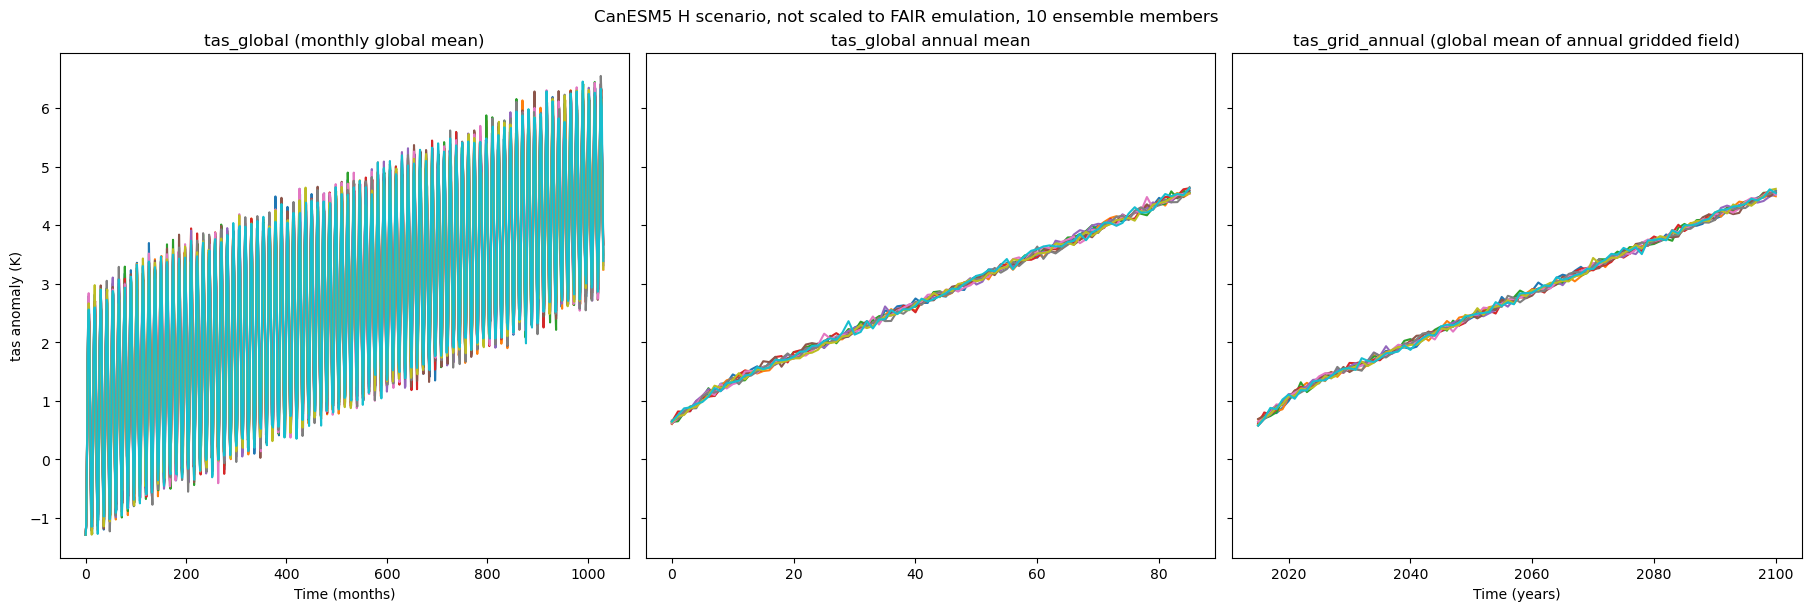

In [24]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6), layout="constrained", sharey=True)
axs[0].plot(tas_monthly['month'], tas_monthly.T.values)
axs[0].set_title('tas_global (monthly global mean)')
axs[0].set_xlabel('Time (months)')
axs[0].set_ylabel('tas anomaly (K)')
axs[1].plot(tas_monthly_annual['month'], tas_monthly_annual.T.values)
axs[1].set_title('tas_global annual mean')
axs[2].plot(tas_annual_glb_mean['year'], tas_annual_glb_mean.values)
axs[2].set_title('tas_grid_annual (global mean of annual gridded field)')
axs[2].set_xlabel('Time (years)')
fig.suptitle('CanESM5 H scenario, not scaled to FAIR emulation, 10 ensemble members')


Text(0.5, 0.98, 'CanESM5 H scenario, not scaled to FAIR emulation, 100 ensemble members')

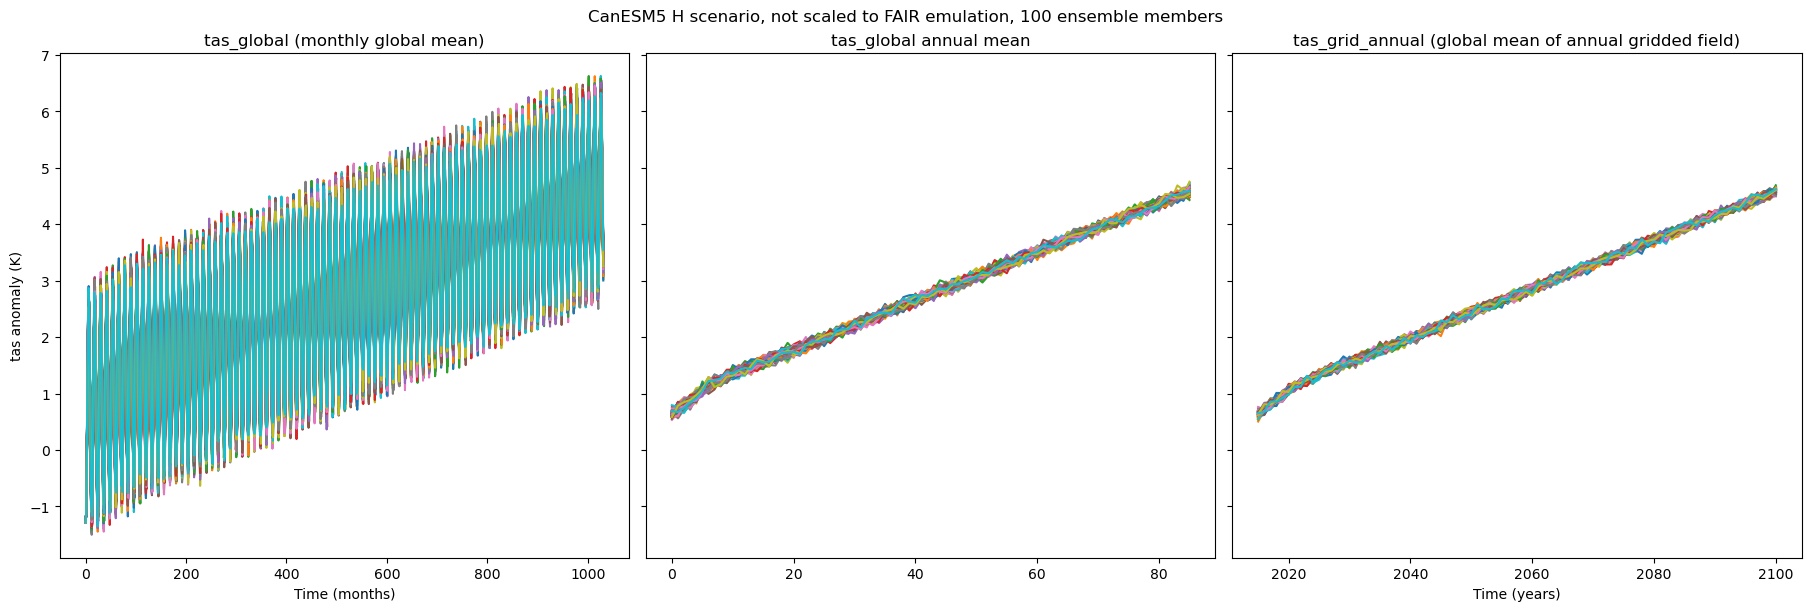

In [27]:
CanESM_H_unscaled_100 = xr.open_dataset("../data/FASTMIP_phase2/METEOR_emulations/raw/METEOR_CanESM5_H_notscaled_n100.nc")

tas_annual_glb_mean = glb_mean(CanESM_H_unscaled_100['tas_grid_annual'])
tas_monthly = CanESM_H_unscaled_100['tas_global']
tas_monthly_annual = tas_monthly.coarsen(month=12, boundary='trim').mean('month')

fig, axs = plt.subplots(1, 3, figsize=(18, 6), layout="constrained", sharey=True)
axs[0].plot(tas_monthly['month'], tas_monthly.T.values)
axs[0].set_title('tas_global (monthly global mean)')
axs[0].set_xlabel('Time (months)')
axs[0].set_ylabel('tas anomaly (K)')
axs[1].plot(tas_monthly_annual['month'], tas_monthly_annual.T.values)
axs[1].set_title('tas_global annual mean')
axs[2].plot(tas_annual_glb_mean['year'], tas_annual_glb_mean.values)
axs[2].set_title('tas_grid_annual (global mean of annual gridded field)')
axs[2].set_xlabel('Time (years)')
fig.suptitle('CanESM5 H scenario, not scaled to FAIR emulation, 100 ensemble members')

Text(0.5, 0.98, 'CanESM5 H scenario, not scaled to FAIR emulation, 10 ensemble members')

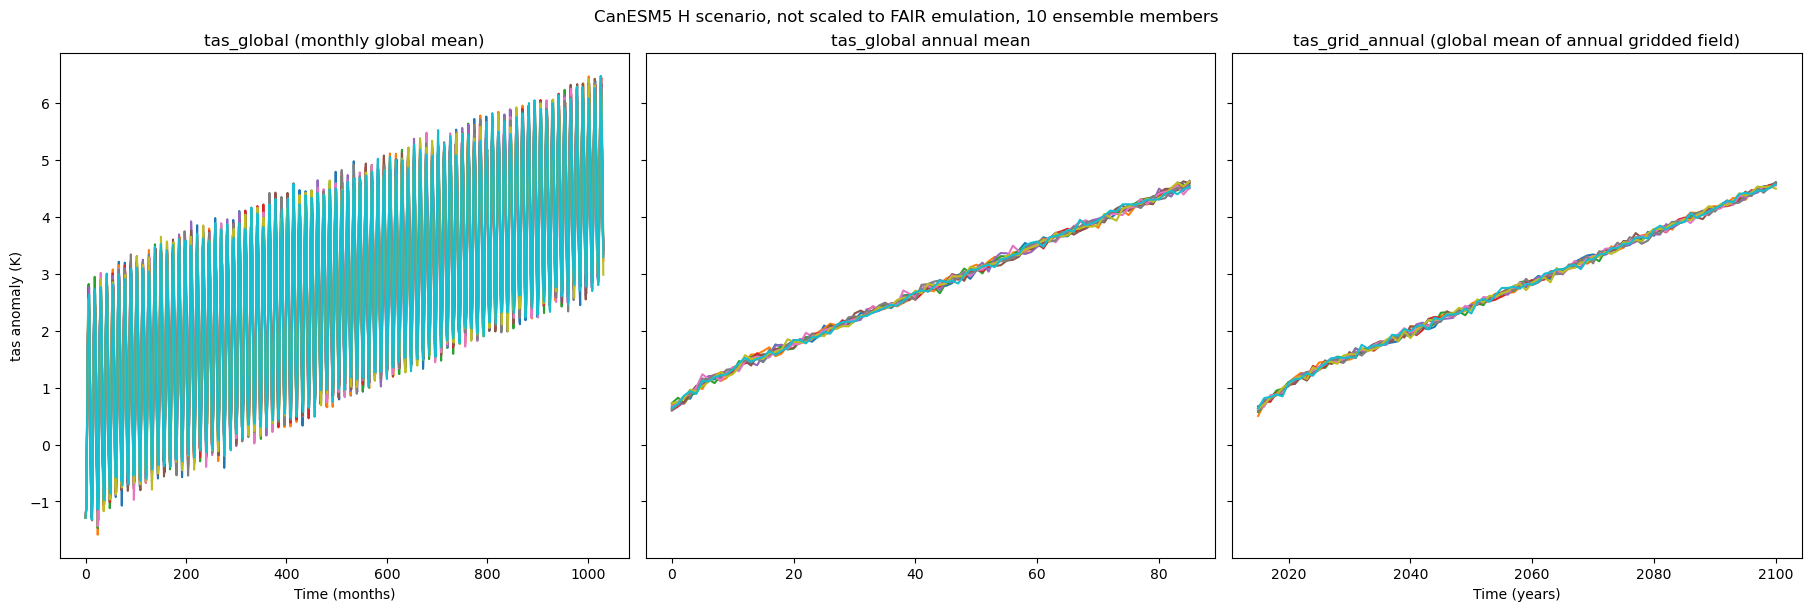

In [ ]:
CanESM_H_unscaled_noisetrue = xr.open_dataset("../data/FASTMIP_phase2/METEOR_emulations/raw/METEOR_CanESM5_H_notscaled_includenoiseTRUE.nc")

tas_annual_glb_mean = glb_mean(CanESM_H_unscaled_noisetrue['tas_grid_annual'])
tas_monthly = CanESM_H_unscaled_noisetrue['tas_global']
tas_monthly_annual = tas_monthly.coarsen(month=12, boundary='trim').mean('month')

fig, axs = plt.subplots(1, 3, figsize=(18, 6), layout="constrained", sharey=True)
axs[0].plot(tas_monthly['month'], tas_monthly.T.values)
axs[0].set_title('tas_global (monthly global mean)')
axs[0].set_xlabel('Time (months)')
axs[0].set_ylabel('tas anomaly (K)')
axs[1].plot(tas_monthly_annual['month'], tas_monthly_annual.T.values)
axs[1].set_title('tas_global annual mean')
axs[2].plot(tas_annual_glb_mean['year'], tas_annual_glb_mean.values)
axs[2].set_title('tas_grid_annual (global mean of annual gridded field)')
axs[2].set_xlabel('Time (years)')
fig.suptitle('CanESM5 H scenario, not scaled to FAIR emulation, 10 ensemble members')

Text(0.5, 0.98, 'MPI-ESM1-2-LR H scenario, not scaled to FAIR emulation, 10 ensemble members')

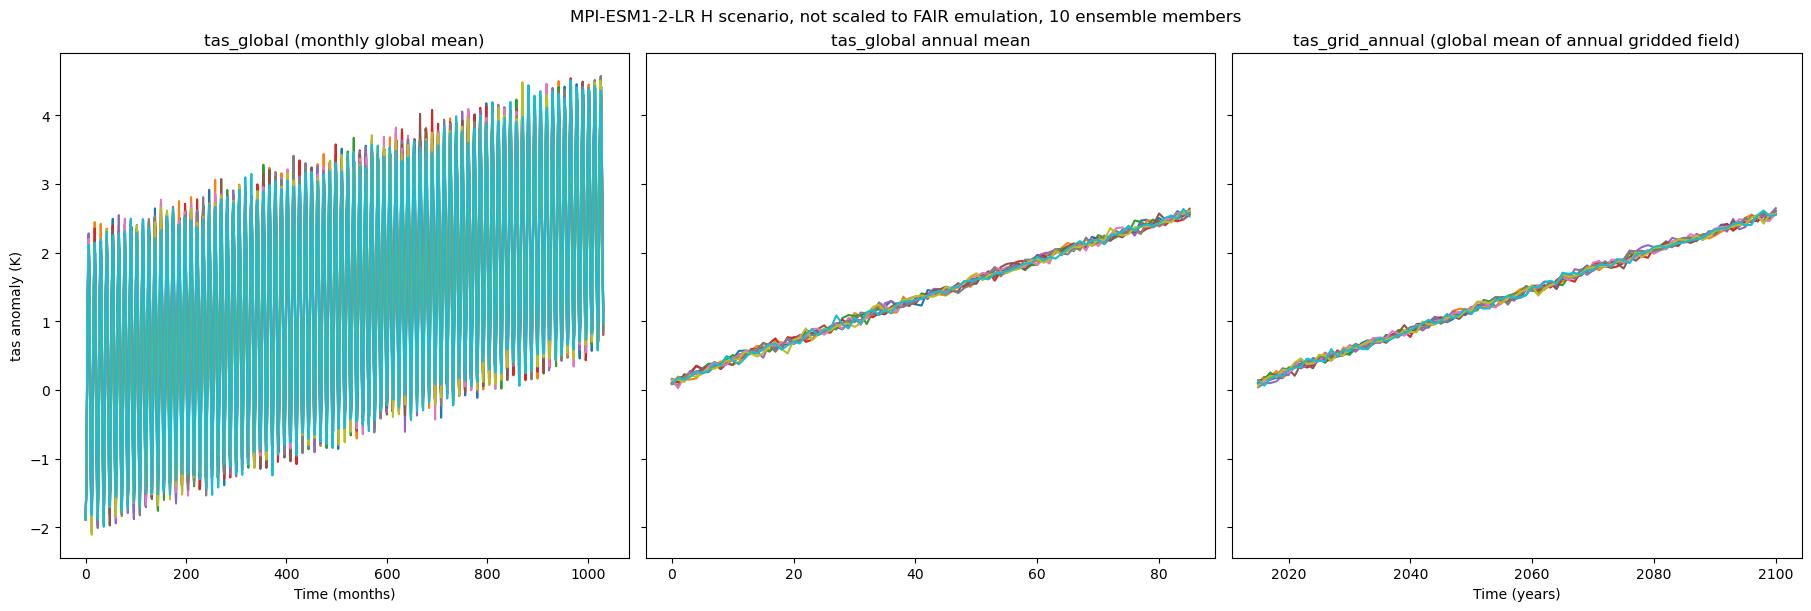

In [4]:
MPI_H_unscaled = xr.open_dataset("../data/FASTMIP_phase2/METEOR_emulations/raw/METEOR_MPI-ESM1-2-LR_H_notscaled.nc")

tas_annual_glb_mean = glb_mean(MPI_H_unscaled['tas_grid_annual'])
tas_monthly = MPI_H_unscaled['tas_global']
tas_monthly_annual = tas_monthly.coarsen(month=12, boundary='trim').mean('month')

fig, axs = plt.subplots(1, 3, figsize=(18, 6), layout="constrained", sharey=True)
axs[0].plot(tas_monthly['month'], tas_monthly.T.values)
axs[0].set_title('tas_global (monthly global mean)')
axs[0].set_xlabel('Time (months)')
axs[0].set_ylabel('tas anomaly (K)')
axs[1].plot(tas_monthly_annual['month'], tas_monthly_annual.T.values)
axs[1].set_title('tas_global annual mean')
axs[2].plot(tas_annual_glb_mean['year'], tas_annual_glb_mean.values)
axs[2].set_title('tas_grid_annual (global mean of annual gridded field)')
axs[2].set_xlabel('Time (years)')
fig.suptitle('MPI-ESM1-2-LR H scenario, not scaled to FAIR emulation, 10 ensemble members')

In [5]:
MPI_H_unscaled

<xarray.Dataset> Size: 254MB
Dimensions:          (year: 86, realization: 10, lat: 96, lon: 192, month: 1032)
Coordinates:
  * year             (year) int64 688B 2015 2016 2017 2018 ... 2098 2099 2100
  * lat              (lat) float64 768B -88.57 -86.72 -84.86 ... 86.72 88.57
  * lon              (lon) float64 2kB 0.0 1.875 3.75 ... 354.4 356.2 358.1
Dimensions without coordinates: realization, month
Data variables:
    tas_grid_annual  (year, realization, lat, lon) float64 127MB 0.2789 ... 7...
    tas_global       (realization, month) float64 83kB ...
    pr_grid_annual   (year, realization, lat, lon) float64 127MB ...
    pr_global        (realization, month) float64 83kB ...
Attributes:
    model:           MPI-ESM1-2-LR
    scenario:        custom
    year_range:      2015-2100
    n_realizations:  10

Text(0.5, 0.98, 'MPI-ESM1-2-LR H scenario, not scaled to FAIR emulation, 10 ensemble members')

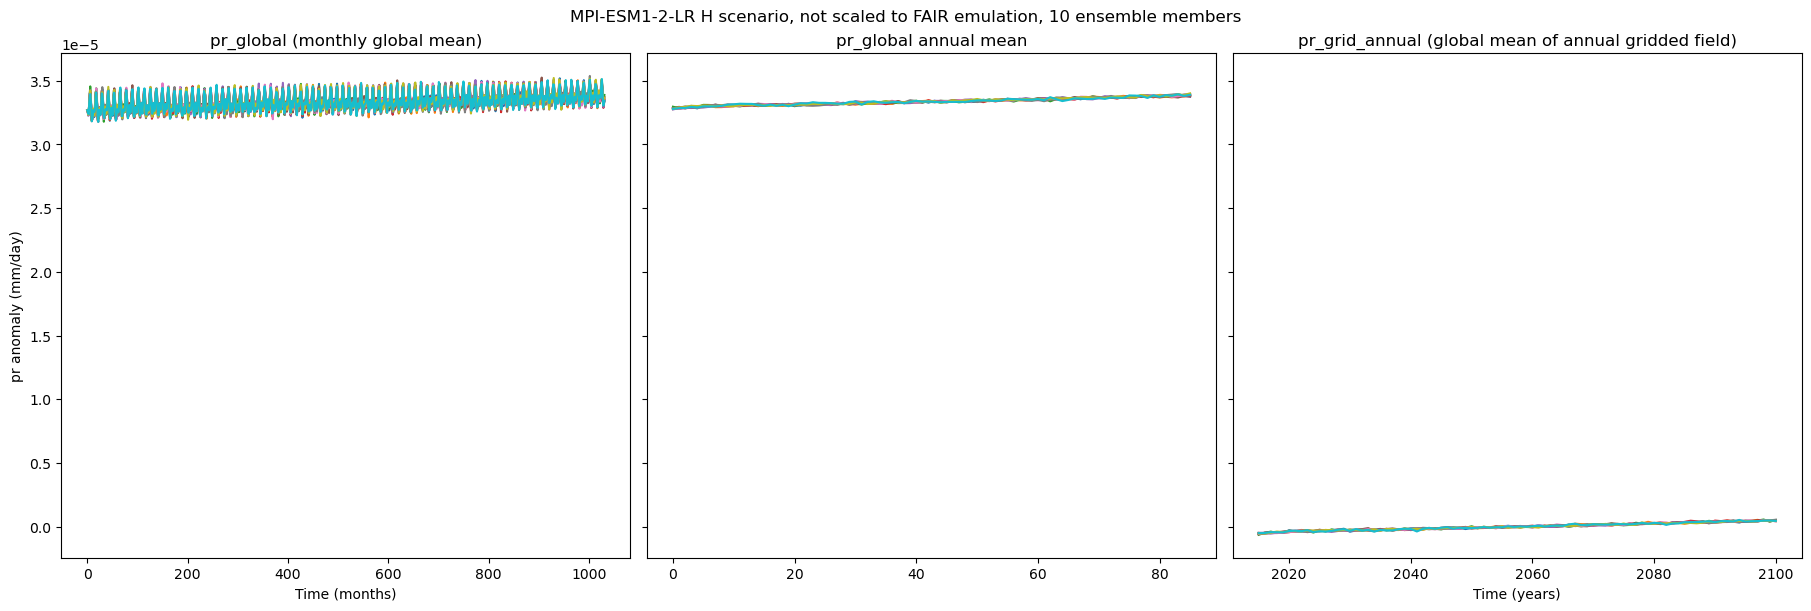

In [6]:
pr_annual_glb_mean = glb_mean(MPI_H_unscaled['pr_grid_annual'])
pr_monthly = MPI_H_unscaled['pr_global']
pr_monthly_annual = pr_monthly.coarsen(month=12, boundary='trim').mean('month')

fig, axs = plt.subplots(1, 3, figsize=(18, 6), layout="constrained", sharey=True)
axs[0].plot(pr_monthly['month'], pr_monthly.T.values)
axs[0].set_title('pr_global (monthly global mean)')
axs[0].set_xlabel('Time (months)')
axs[0].set_ylabel('pr anomaly (mm/day)')
axs[1].plot(pr_monthly_annual['month'], pr_monthly_annual.T.values)
axs[1].set_title('pr_global annual mean')
axs[2].plot(pr_annual_glb_mean['year'], pr_annual_glb_mean.values)
axs[2].set_title('pr_grid_annual (global mean of annual gridded field)')
axs[2].set_xlabel('Time (years)')
fig.suptitle('MPI-ESM1-2-LR H scenario, not scaled to FAIR emulation, 10 ensemble members')